In [118]:
import numpy as np
from itertools import combinations

lstms_stack = np.load('lstms_stack.npy')

n_repeats = 32
n_maps = 32
n_samples = 4501
n_players = 4
n_pairs = n_players * (n_players - 1) // 2
pairs = combinations(np.arange(n_players), 2)
n_pcs = 142
pc_pairs = n_pcs*(n_pcs-1)//2 + n_pcs
n_components = 142
n_teams = 2

In [2]:
lstms_stack.shape

(4609024, 4, 142)

In [5]:
a_lstms = lstms_stack[:144032,0,:]
b_lstms = lstms_stack[:144032,1,:]
a_lstms.shape

(144032, 142)

### CCA

In [6]:
from sklearn.cross_decomposition import CCA

cca = CCA(n_components=n_components)
'''cca.fit(X_train, Y_train)
X_train_r, Y_train_r = cca.transform(X_train, Y_train)
X_test_r, Y_test_r = cca.transform(X_test, Y_test)'''
a_scores, b_scores = cca.fit_transform(a_lstms, b_lstms)

In [12]:
np.save('cca_map1_team1_results.npy', (a_scores, b_scores))

In [13]:
a_scores, b_scores = np.load('cca_map1_team1_results.npy')

In [15]:
print(cca.x_weights_.shape,
cca.y_weights_.shape,
cca.x_loadings_.shape,
cca.y_loadings_.shape,
cca.x_rotations_.shape,
cca.y_rotations_.shape,
cca.coef_.shape,
a_scores.shape, 
b_scores.shape)

#weights: left & right singular vectors of the corr. matrix of X,Y corresponding to the highest singular value
#loadings: (INCONSISTENT NOMENCLATURE) correlation between X/Y var.s and X/Y canonical variates
#rotations: transformation matrix (X->U and Y->V)
#coef: coefficients in the final correlation
#scores: dataset transformed into canonical variables (n_components)

(142, 100) (142, 100) (142, 100) (142, 100) (142, 100) (142, 100) (142, 142) (144032, 100) (144032, 100)


<BarContainer object of 100 artists>

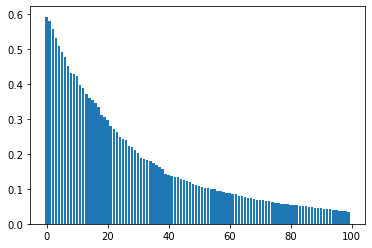

In [107]:
import matplotlib.pyplot as plt

comp_corr = [np.corrcoef(a_scores[:, i], b_scores[:, i])[1][0] for i in range(n_ccs)]
plt.bar(range(n_ccs), comp_corr)

In [ ]:
### OLD - by map ###

from sklearn.cross_decomposition import CCA
from tqdm import tqdm

teams=[(0,1), (2,3)]
for map_id in tqdm(range(22,n_maps)):
    for i, team in enumerate(teams):
        a_lstms = lstms_stack[144032*map_id:144032*(map_id+1),team[0],:]
        b_lstms = lstms_stack[144032*map_id:144032*(map_id+1),team[1],:]

        cca = CCA(n_components=n_components)
        a_scores, b_scores = cca.fit_transform(a_lstms, b_lstms)
        np.save(f'cca_map{map_id+1}_team{i+1}_results.npy', (a_scores, b_scores))
        print(f'cca_map{map_id+1}_team{i+1}_results.npy saved')

In [ ]:
from sklearn.cross_decomposition import CCA
from tqdm import tqdm

teams=[(0,1), (2,3)]
for map_id in range(n_maps):
    for repeat_id in tqdm(range(n_repeats)):
        for i, team in enumerate(teams):
            a_lstms = lstms_stack[144032*map_id+4501*repeat_id:144032*map_id+4501*(repeat_id+1),team[0],:]
            b_lstms = lstms_stack[144032*map_id+4501*repeat_id:144032*map_id+4501*(repeat_id+1),team[1],:]

            cca = CCA(n_components=n_components)
            a_scores, b_scores = cca.fit_transform(a_lstms, b_lstms)
            np.save(f'cca_map{map_id+1}_repeat{repeat_id+1}_team{i+1}_results.npy', (a_scores, b_scores))
            print(f'cca_map{map_id+1}_repeat{repeat_id+1}_team{i+1}_results.npy saved')

In [105]:
a_scores, b_scores = agent_1, agent_2

### ISCs - OLD

In [52]:
n_ccs=n_components

map_ids = []
for map_id in np.arange(n_maps):
    map_ids.extend([map_id]*n_repeats)
len(map_ids)

1024

In [ ]:
agent_1, agent_2 = np.load(f'cca_map{map_id+1}_team{pair_id+1}_results.npy')
agent_1.shape

(144032, 100)

In [100]:
from sklearn.model_selection import PredefinedSplit
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
cv = PredefinedSplit(map_ids)

coefs = np.full((n_ccs, 2, n_maps*n_repeats), np.nan)
results = np.full((n_ccs, 2, n_maps), np.nan)  #n_repeats
#pairs = combinations(np.arange(n_players), 2)
for pair_id, pair in enumerate(teams):
    for cc_id in np.arange(n_ccs):
        result = []
        ##coef = []
        for map_id in tqdm(np.arange(n_maps)):
            agent_1, agent_2 = np.load(f'cca_map{map_id+1}_team{pair_id+1}_results.npy')
            if np.isnan(agent_1).any() or  np.isnan(agent_2).any():
                print(np.isnan(agent_1).any(), np.isnan(agent_2).any())
            #for fold, (train, test) in enumerate(cv.split()):
            reg = LinearRegression()
            reg.fit(agent_1[train, cc_id][:, np.newaxis], 
                    agent_2[train, cc_id])
            #if pc_id==1:
            #    raise
            coefs[cc_id, pair_id, fold] = reg.coef_
            ##coef.extend([reg.coef_ for i in range(n_repeats)])
            pred = reg.predict(agent_1[test, cc_id][:, np.newaxis])
            result.extend([pearsonr(pred, agent_2[test, cc_id])[0]])
            #print(len(result))
            '''result.extend([pearsonr(p, t)[0] for p, t in
                           zip(np.split(pred, n_repeats, axis=0),
                               np.split(agent_2[test, cc_id], n_repeats, axis=0))])'''
        print(f"Finished ISC regressions for CC {cc_id}")#, pair {pair_id}") #fold {fold}
        results[cc_id, pair_id] = np.array(result)
        ##coefs[pc_id, pair_id] = np.array(coef)

100%|███████████████████████████████████████████████████████████████████████████████████| 32/32 [00:11<00:00,  2.89it/s]


Finished ISC regressions for CC 0


  9%|███████▉                                                                            | 3/32 [00:01<00:11,  2.60it/s]


KeyboardInterrupt: 

In [109]:
np.isnan(results[:,0,:]).any()
np.argwhere(np.isnan(results[:,:1,:]))
results = results[:,:2,:]

In [65]:
for i in pairs:
    print(i)

(0, 1)
(0, 2)
(0, 3)
(1, 2)
(1, 3)
(2, 3)


In [82]:
results.shape

(100, 2, 32)

In [110]:
results[70]

array([[-1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,
        -1.,  1., -1.,  1.,  1., -1.,  1., -1., -1.,  1., -1.,  1., -1.,
         1., -1.,  1.,  1.,  1.,  1.],
       [ 1., -1.,  1.,  1.,  1.,  1., -1., -1.,  1.,  1.,  1., -1., -1.,
        -1., -1., -1., -1.,  1., -1.,  1., -1.,  1.,  1., -1., -1.,  1.,
         1., -1., -1., -1.,  1.,  1.]])

In [111]:
np.save(f'ISC_CCA_results.npy', results)

In [108]:
results = np.load(f'ISC_CCA_results.npy')

In [ ]:
import pandas as pd

results_df_dict_full = {'CC': [], 'coop coef': [], 'comp coef': [], 'cooperative cvISC': [], 'competitive cvISC': [], 'cooperative-competitive cvISC difference': []}

coop_ids = (0, 5)
comp_ids = (1, 2, 3, 4)
for pc_id in np.arange(n_pcs): 
    for map_id in np.arange(n_maps):
        for repeat_id in np.arange(n_repeats):
            game_id=map_id*n_repeats+repeat_id
            coop = np.mean(results[pc_id, coop_ids, game_id], axis=0)
            #comp = np.mean(results[pc_id, comp_ids, game_id], axis=0)
            #if not np.isnan(coefs[pc_id, 5, game_id]):
            #print(coefs[pc_id, coop_ids, game_id])
            coop_coef = np.mean(coefs[pc_id, coop_ids, map_id], axis=0)
            #comp_coef = np.mean(coefs[pc_id, comp_ids, map_id], axis=0)
            results_df_dict_full['cooperative cvISC'].append(coop)
            #results_df_dict_full['competitive cvISC'].append(comp)
            #results_df_dict_full['cooperative-competitive cvISC difference'].append(coop-comp)
            results_df_dict_full['CC'].append(pc_id + 1)
            results_df_dict_full['coop coef'].append(coop_coef)
            #results_df_dict_full['comp coef'].append(comp_coef)

results_df_full = pd.DataFrame(results_df_dict_full)
results_df_full

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#cols = ['red' if np.mean(results_df_full[results_df_full['PC']==x]['cooperative cvISC']) < 
#        np.mean(results_df_full[results_df_full['PC']==x]['competitive cvISC']) 
#        else 'blue' for x in range(142)]
cols = ['red' if np.mean(results_df_full[results_df_full['CC']==x]['coop coef']) < 0
       else 'blue' for x in range(1,143)]
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='CC', y='cooperative cvISC', data=results_df_full, palette=cols) #color='gray')
ax.set_ylim(0, .4) #was using .6?
ax.set_title('Cooperative cvISCs for 142 CCs', fontsize=20)
plt.xlabel('CC', fontsize=16);
plt.ylabel('cooperative cvISC', fontsize=16);
fig.savefig("coop_cvISC.png")

In [ ]:
#cols = ['red' if np.mean(results_df_full[results_df_full['PC']==x]['cooperative cvISC']) < 
#        np.mean(results_df_full[results_df_full['PC']==x]['competitive cvISC']) 
#        else 'blue' for x in range(142)]
cols = ['red' if np.mean(results_df_full[results_df_full['CC']==x]['comp coef']) < 0
       else 'blue' for x in range(1,143)]
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='CC', y='competitive cvISC', data=results_df_full, palette=cols)# color='gray')
ax.set_ylim(0, .4) #was using .6?
ax.set_title('Competitive Pair cvISCs for 142 CCs', fontsize=20)
plt.xlabel('CC', fontsize=16);
plt.ylabel('competitive cvISC', fontsize=16);
fig.savefig("comp_cvISC.png")

### ISCs

In [125]:
#import matplotlib.pyplot as plt
#from tqdm import tqdm 

iscs = np.full((n_ccs, n_teams, n_maps*n_repeats), np.nan)
for map_id in range(n_maps):
    for repeat_id in tqdm(range(n_repeats)):
        for team_id in range(n_teams):
            agent_1, agent_2 = np.load(f'cca_map{map_id+1}_repeat{repeat_id+1}_team{team_id+1}_results.npy')
            for cc_id in range(n_ccs):
                iscs[cc_id, team_id, repeat_id+map_id*32] = np.corrcoef(agent_1[:, cc_id], agent_2[:, cc_id])[1][0]

100%|███████████████████████████████████████████████████████████████████████████████████| 32/32 [00:06<00:00,  5.06it/s]


In [126]:
np.save(f'cca_iscs.npy', iscs)
iscs.shape

(142, 2, 1024)

In [139]:
results_df_dict_full = {'CC': [], 'cooperative cvISC': []}

coop_ids = (0, 5)
comp_ids = (1, 2, 3, 4)
for cc_id in np.arange(n_ccs): 
    for map_id in np.arange(n_maps):
        for repeat_id in np.arange(n_repeats):
            game_id=map_id*n_repeats+repeat_id
            coop = np.mean(iscs[cc_id, :, game_id], axis=0)
            #if not np.isnan(coefs[pc_id, 5, game_id]):
            #print(coefs[pc_id, coop_ids, game_id])
            results_df_dict_full['cooperative cvISC'].append(coop)
            results_df_dict_full['CC'].append(cc_id + 1)

results_df_full = pd.DataFrame(results_df_dict_full)
results_df_full

,CC,cooperative cvISC
0,1,0.802248
1,1,0.806197
2,1,0.801630
3,1,0.814532
4,1,0.809590
...,...,...
145403,142,0.000706
145404,142,0.001136
145405,142,0.000411
145406,142,0.002100


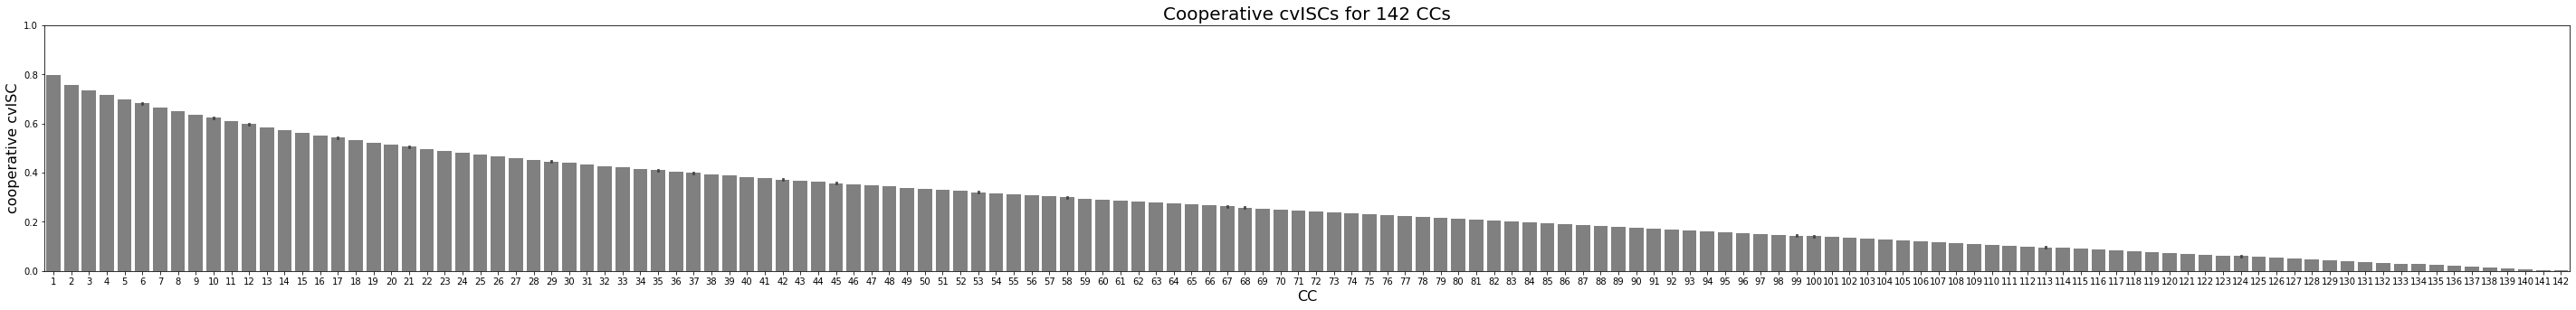

In [146]:
#cols = ['red' if np.mean(results_df_full[results_df_full['CC']==x]['coop coef']) < 0
#       else 'blue' for x in range(1,143)]
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='CC', y='cooperative cvISC', data=results_df_full, color='gray') # palette=cols)
ax.set_ylim(0, 1)
ax.set_title('Cooperative cvISCs for 142 CCs', fontsize=20)
plt.xlabel('CC', fontsize=16);
plt.ylabel('cooperative cvISC', fontsize=16);

In [124]:
n_ccs = 142

In [113]:
agent_1, agent_2 = np.load(f'cca_map{map_id+1}_team{pair_id+1}_results.npy')
agent_1.shape

(144032, 100)

### Wins and Score Prediction

In [37]:
wins = np.load(f'/jukebox/hasson/snastase/social-ctf/results/wins_matchup-0.npy')
scores = np.load(f'/jukebox/hasson/snastase/social-ctf/results/scores_matchup-0.npy')

In [39]:
win_stack = np.hstack(np.split(wins, n_repeats, axis=0)).squeeze() #32 x 144032 x 2
print(f"Wins stack shape: {win_stack.shape}")
score_stack = np.hstack(np.split(scores, n_repeats, axis=0)).squeeze() #32 x 144032 x 2
print(f"Scores stack shape: {score_stack.shape}")

Wins stack shape: (1024, 2)
Scores stack shape: (1024, 2)


In [ ]:
### issue: CCA not symetric output - cannot directly use for regression
### could combine x_loadings and y_loadings?

In [40]:
from sklearn.model_selection import PredefinedSplit

# Create a new split over games (not samples)
map_ids_2 = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        map_ids_2.append(map_id)
        
cv2 = PredefinedSplit(map_ids_2)

In [153]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from scipy.stats import zscore

teams = (0,1)
cvISC_stack = np.hstack((iscs[:, teams[0], :], iscs[:, teams[1], :]))#.squeeze()[:, np.newaxis]
print(cvISC_stack.shape)
#print(np.argwhere(np.isnan(cvISC_stack)))

wins_stack = np.concatenate((win_stack[:, 0], win_stack[:, 1]), axis=0)
print(wins_stack.shape)
cv3 = KFold(n_splits=32) 

results_wins = np.full((n_ccs, n_maps), np.nan)   #n_repeats
coefs_wins = np.full((n_ccs, n_maps), np.nan)   #n_repeats
#pairs = [(0,1),(2,3)]
for cc_id in np.arange(n_ccs):
    '''ccs
    for pair_id, pair in enumerate(pairs):
        agent_1, agent_2 = np.load(f'cca_map{map_id+1}_team{pair_id+1}_results.npy')
    print(ccs.shape)'''
    for f, (train, test) in enumerate(cv3.split(cvISC_stack[0])):#enumerate(cv2.split()):             
        # Initialize simple classifier
        clf = LogisticRegression(penalty='none', max_iter=300, class_weight='balanced') 

        # Z-score training and test cvISCs (based on training set)
        results_train = zscore(cvISC_stack[cc_id, train][:, np.newaxis])  #result, pair_id*5
        results_test = zscore(cvISC_stack[cc_id, test][:, np.newaxis])
        #print(f, np.argwhere(np.isnan(results_test)), np.argwhere(np.isnan(results_train)))
        #print(cvISC_stack[cc_id, test], results_test)

        # Train logistic regression
        clf.fit(results_train, wins_stack[train])#, pair_id])

        # Predict test wins 
        pred = clf.predict(results_test)

        # Evaluate classifier accuracy
        score = accuracy_score(wins_stack[test], pred) #pair_id
        #scores.append(score)

        # Keep coefficient
        coefs_wins[cc_id, f] = clf.coef_ #pair_id
        results_wins[cc_id, f] = score #np.array(scores) #pair_id
    print(f"Finished wins regression for CC {cc_id}") 

(142, 2048)
(2048,)
Finished wins regression for CC 0
Finished wins regression for CC 1
Finished wins regression for CC 2
Finished wins regression for CC 3
Finished wins regression for CC 4
Finished wins regression for CC 5
Finished wins regression for CC 6
Finished wins regression for CC 7
Finished wins regression for CC 8
Finished wins regression for CC 9
Finished wins regression for CC 10
Finished wins regression for CC 11
Finished wins regression for CC 12
Finished wins regression for CC 13
Finished wins regression for CC 14
Finished wins regression for CC 15
Finished wins regression for CC 16
Finished wins regression for CC 17
Finished wins regression for CC 18
Finished wins regression for CC 19
Finished wins regression for CC 20
Finished wins regression for CC 21
Finished wins regression for CC 22
Finished wins regression for CC 23
Finished wins regression for CC 24
Finished wins regression for CC 25
Finished wins regression for CC 26
Finished wins regression for CC 27
Finished w

In [154]:
import pandas as pd

results_df_dict_wins = {'CC': [], 'wins coop': [], 'coef': []}

for cc_id in np.arange(n_ccs): 
    for game_id in np.arange(n_maps): #n_repeats
        wins_coop = results_wins[cc_id, game_id] #np.mean(results_wins[pc_id, (0,1), game_id], axis=0)
        coef = coefs_wins[cc_id, game_id]
        results_df_dict_wins['wins coop'].append(wins_coop)
        results_df_dict_wins['CC'].append(cc_id + 1)
        results_df_dict_wins['coef'].append(coef)

results_df_wins = pd.DataFrame(results_df_dict_wins)
results_df_wins

,CC,wins coop,coef
0,1,0.484375,-0.074053
1,1,0.531250,-0.081944
2,1,0.500000,-0.069810
3,1,0.546875,-0.061616
4,1,0.546875,-0.071100
...,...,...,...
4539,142,0.390625,-0.062446
4540,142,0.390625,-0.066615
4541,142,0.484375,-0.055496
4542,142,0.531250,-0.058383


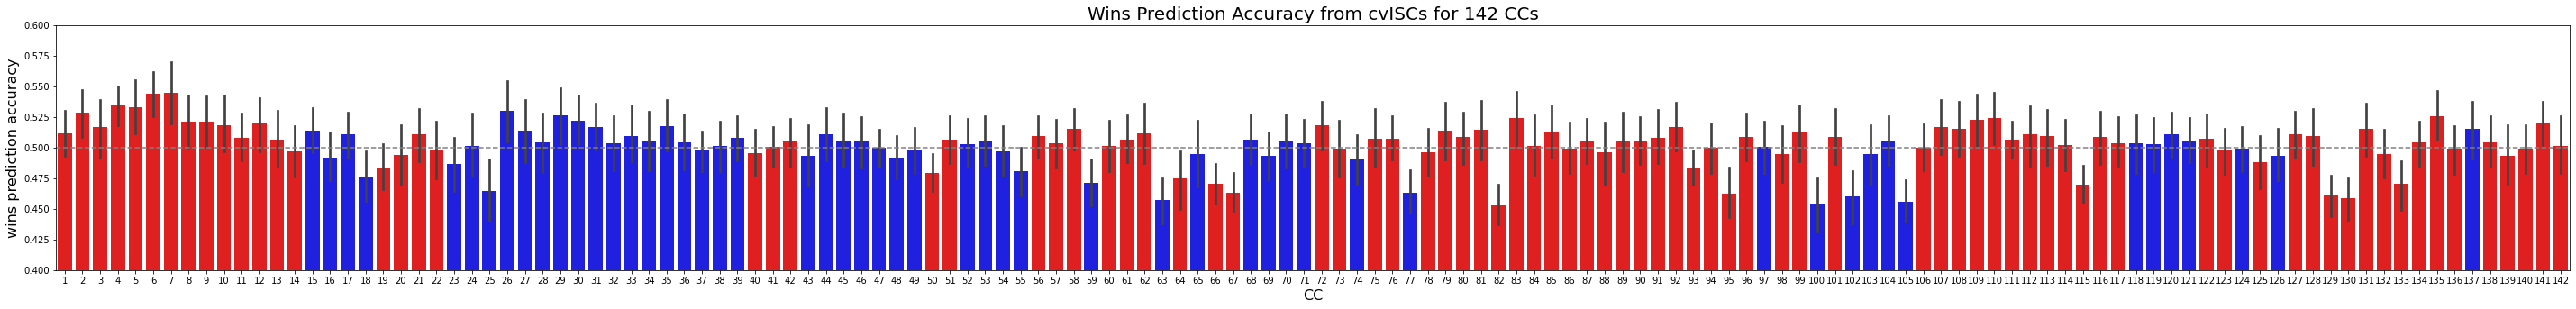

In [155]:
cols = ['red' if np.mean(results_df_wins[results_df_wins['CC']==x]['coef']) < 0
       else 'blue' for x in range(1,143)]
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='CC', y='wins coop', data=results_df_wins, palette=cols) #color='gray')
ax.set_ylim(0.4, .6)
ax.set_title('Wins Prediction Accuracy from cvISCs for 142 CCs', fontsize=20)
plt.xlabel('CC', fontsize=16);
plt.ylabel('wins prediction accuracy', fontsize=16);

# insert horizontal line (gray dotted) at 50
plt.axhline(y=.5, ls='--', c='gray')

In [156]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from scipy.stats import pearsonr

teams = (0,1)
cvISC_stack = np.hstack((iscs[:, teams[0], :], iscs[:, teams[1], :]))#.squeeze()[:, np.newaxis]
print(cvISC_stack.shape)
scores_stack = np.concatenate((score_stack[:, 0], score_stack[:, 1]), axis=0)
print(scores_stack.shape)
cv3 = KFold(n_splits=32) 

results_scores = np.full((n_ccs, n_maps), np.nan)   #n_repeats
coefs_scores = np.full((n_ccs, n_maps), np.nan)
for cc_id in np.arange(n_ccs):
    pairs = [(0, (0,1)), (5, (2,3))]
    #for pair_id, pair in pairs:
    #    scores = []
    for f, (train, test) in enumerate(cv3.split(cvISC_stack[0])):
        # Initialize simple classifier
        clf = LinearRegression() 

        # Z-score training and test cvISCs (based on training set)
        results_train = zscore(cvISC_stack[cc_id, train][:, np.newaxis]) 
        results_test = zscore(cvISC_stack[cc_id, test][:, np.newaxis])

        # Train linear regression
        clf.fit(results_train, scores_stack[train])

        # Predict test wins 
        pred = clf.predict(results_test)

        # Evaluate classifier accuracy
        r = pearsonr(pred, scores_stack[test])[0]
        #scores.append(r)

        # Keep coefficient
        coefs_scores[cc_id, f] = clf.coef_  #pair_id//5
        results_scores[cc_id, f] = r #np.array(scores)
    print(f"Finished scores regression for CC {cc_id}") 

(142, 2048)
(2048,)
Finished scores regression for CC 0
Finished scores regression for CC 1
Finished scores regression for CC 2
Finished scores regression for CC 3
Finished scores regression for CC 4
Finished scores regression for CC 5
Finished scores regression for CC 6
Finished scores regression for CC 7
Finished scores regression for CC 8
Finished scores regression for CC 9
Finished scores regression for CC 10
Finished scores regression for CC 11
Finished scores regression for CC 12
Finished scores regression for CC 13
Finished scores regression for CC 14
Finished scores regression for CC 15
Finished scores regression for CC 16
Finished scores regression for CC 17
Finished scores regression for CC 18
Finished scores regression for CC 19
Finished scores regression for CC 20
Finished scores regression for CC 21
Finished scores regression for CC 22
Finished scores regression for CC 23
Finished scores regression for CC 24
Finished scores regression for CC 25
Finished scores regression f

In [157]:
results_df_dict_scores = {'CC': [], 'scores coop': [], 'coef': []}# 'score diffs coop': [],, 'score diffs comp': []} #'wins comp': [],

coop_ids = (0, 5)
comp_ids = (1, 2, 3, 4)
for cc_id in np.arange(n_ccs): 
    for game_id in np.arange(n_maps):# * n_repeats):
        #scores_coop_diffs = np.mean(results_scores_diffs[pc_id])
        scores_coop = results_scores[cc_id, game_id]
        coef = coefs_scores[cc_id, game_id]
        #results_df_dict_scores['score diffs coop'].append(scores_coop_diffs)
        results_df_dict_scores['scores coop'].append(scores_coop)
        results_df_dict_scores['CC'].append(cc_id + 1)
        results_df_dict_scores['coef'].append(coef)

results_df_scores = pd.DataFrame(results_df_dict_scores)
results_df_scores

,CC,scores coop,coef
0,1,0.207211,-0.397624
1,1,-0.031335,-0.424414
2,1,0.170652,-0.402018
3,1,0.194677,-0.390257
4,1,0.176674,-0.378973
...,...,...,...
4539,142,-0.094727,-0.016993
4540,142,-0.044868,-0.015533
4541,142,0.026321,-0.009587
4542,142,-0.026243,-0.013640


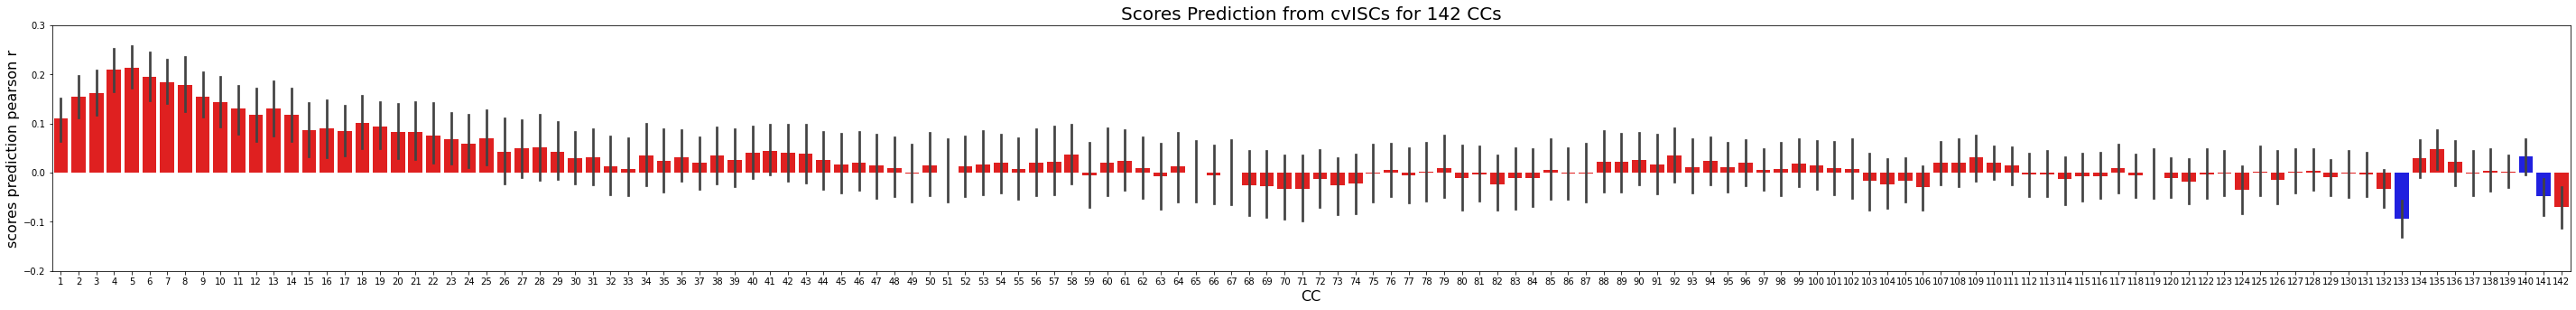

In [158]:
cols = ['red' if np.mean(results_df_scores[results_df_scores['CC']==x]['coef']) < 0
       else 'blue' for x in range(1,143)]
#cols = ['red' if np.mean(results_df_scores_diff[results_df_scores_diff['PC']==x]['scores diff coop']) < 0 else 'blue' for x in range(1,143)]
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='CC', y='scores coop', data=results_df_scores, palette=cols)#color='gray')
ax.set_ylim(-.2, .3)
ax.set_title('Scores Prediction from cvISCs for 142 CCs', fontsize=20)
plt.xlabel('CC', fontsize=16);
plt.ylabel('scores prediction pearson r', fontsize=16);

In [159]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from scipy.stats import pearsonr

results_scores_diff = np.full((n_ccs, n_maps), np.nan)   #n_repeats
coefs_scores_diff = np.full((n_ccs, n_maps), np.nan)
for cc_id in np.arange(n_ccs):
    scores = []
    for f, (train, test) in enumerate(cv2.split()):
        # Initialize simple classifier
        clf = LinearRegression() 

        # Z-score training and test cvISCs (based on training set)
        results_train = zscore((iscs[cc_id, 0, train]-iscs[cc_id, 1, train])[:, np.newaxis]) 
        results_test = zscore((iscs[cc_id, 0, test]-iscs[cc_id, 1, test])[:, np.newaxis])

        # Train logistic regression
        clf.fit(results_train, score_stack[train, 0]-score_stack[train, 1])

        # Predict test wins 
        pred = clf.predict(results_test)

        # Evaluate classifier accuracy
        r = pearsonr(pred, score_stack[test, 0]-score_stack[test, 1])[0]
        scores.append(r)
        
        # Keep coefficient
        coefs_scores_diff[cc_id, f] = clf.coef_
    results_scores_diff[cc_id] = np.array(scores)
    print(f"Finished scores regression for CC {cc_id}") 
print(f"Shape of results: {results_scores_diff.shape}") 

Finished scores regression for CC 0
Finished scores regression for CC 1
Finished scores regression for CC 2
Finished scores regression for CC 3
Finished scores regression for CC 4
Finished scores regression for CC 5
Finished scores regression for CC 6
Finished scores regression for CC 7
Finished scores regression for CC 8
Finished scores regression for CC 9
Finished scores regression for CC 10
Finished scores regression for CC 11
Finished scores regression for CC 12
Finished scores regression for CC 13
Finished scores regression for CC 14
Finished scores regression for CC 15
Finished scores regression for CC 16
Finished scores regression for CC 17
Finished scores regression for CC 18
Finished scores regression for CC 19
Finished scores regression for CC 20
Finished scores regression for CC 21
Finished scores regression for CC 22
Finished scores regression for CC 23
Finished scores regression for CC 24
Finished scores regression for CC 25
Finished scores regression for CC 26
Finished sc

In [160]:
results_df_dict_scores_diff = {'CC': [], 'scores diff coop': [], 'coef': []}# 'score diffs coop': [],, 'score diffs comp': []} #'wins comp': [],

coop_ids = (0, 5)
comp_ids = (1, 2, 3, 4)
for cc_id in np.arange(n_ccs): 
    for game_id in np.arange(n_maps):# * n_repeats):
        #scores_coop_diffs = np.mean(results_scores_diffs[pc_id])
        scores_coop = results_scores_diff[cc_id, game_id] #np.mean(results_scores_diff[pc_id]) 
        coef = coefs_scores_diff[cc_id, game_id] #np.mean(coefs_scores_diff[pc_id]) 
        #results_df_dict_scores['score diffs coop'].append(scores_coop_diffs)
        results_df_dict_scores_diff['scores diff coop'].append(scores_coop)
        results_df_dict_scores_diff['CC'].append(cc_id + 1)
        results_df_dict_scores_diff['coef'].append(coef)

results_df_scores_diff = pd.DataFrame(results_df_dict_scores_diff)
results_df_scores_diff

,CC,scores diff coop,coef
0,1,0.263101,4.182058
1,1,0.099797,4.677820
2,1,-0.315765,6.163646
3,1,-0.168392,5.666124
4,1,-0.026031,4.409041
...,...,...,...
4539,142,-0.001738,6.313053
4540,142,-0.097240,6.434641
4541,142,0.176265,5.660100
4542,142,0.299835,5.086818


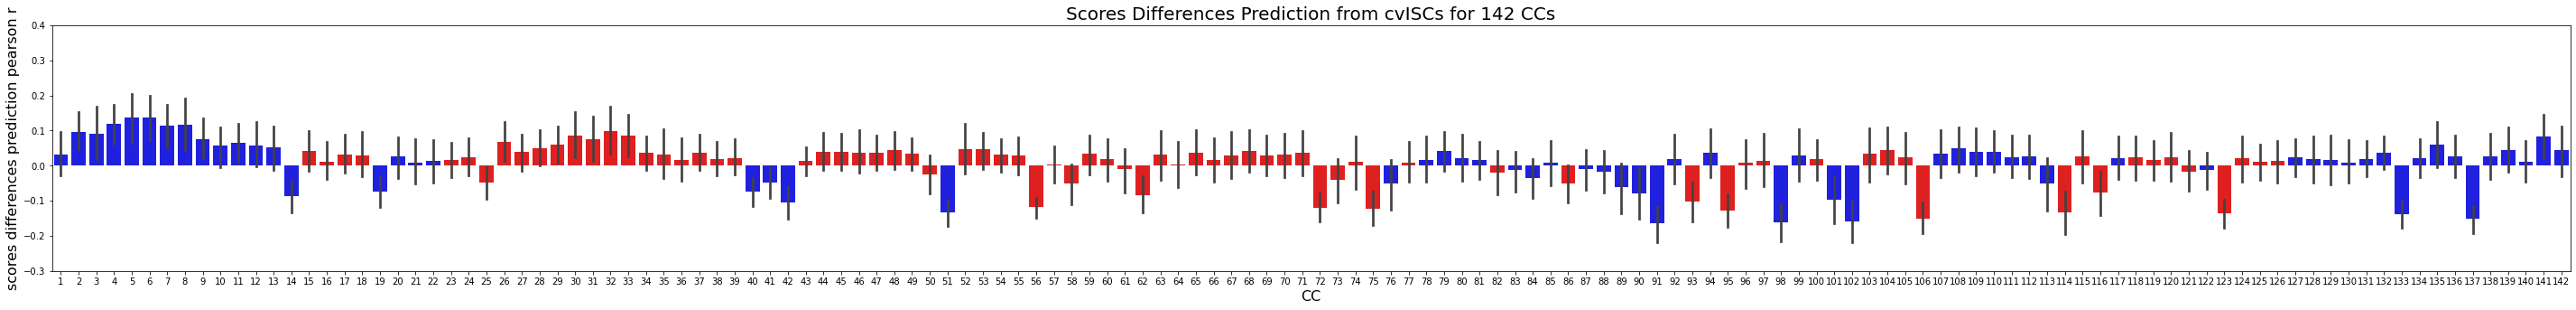

In [161]:
#cols = ['red' if np.mean(results_df_scores_diff[results_df_scores_diff['PC']==x]['scores diff coop']) < 0 else 'blue' for x in range(1,143)]
cols = ['red' if np.mean(results_df_scores_diff[results_df_scores_diff['CC']==x]['coef']) < 0
       else 'blue' for x in range(1,143)]
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='CC', y='scores diff coop', data=results_df_scores_diff, palette=cols)#color='gray')
ax.set_ylim(-.3, .4)
ax.set_title('Scores Differences Prediction from cvISCs for 142 CCs', fontsize=20)
plt.xlabel('CC', fontsize=16);
plt.ylabel('scores differences prediction pearson r', fontsize=16);

### Multiple Regressions

In [ ]:
# Plot CCs for 1 game - timeseries, CCs 1-10